<>:132: SyntaxWarning: invalid escape sequence '\e'
<>:138: SyntaxWarning: invalid escape sequence '\s'
<>:132: SyntaxWarning: invalid escape sequence '\e'
<>:138: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1986693185.py:132: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Input Strain $\epsilon(t)$")
/tmp/ipython-input-1986693185.py:138: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Output Stress $\sigma(t)$\nRel Error: {error_l2*100:.2f}%")


Generating Viscoelastic Data...
Data Stats | Stress Mean: 0.81, Stress Std: 2.34
Training DeepONet (Normalized)...
Epoch 0, Loss: 1.106804
Epoch 500, Loss: 0.284972
Epoch 1000, Loss: 0.185140
Epoch 1500, Loss: 0.053793
Epoch 2000, Loss: 0.048256
Epoch 2500, Loss: 0.019710
Epoch 3000, Loss: 0.024654
Epoch 3500, Loss: 0.012733
Epoch 4000, Loss: 0.011177
Epoch 4500, Loss: 0.009575
Epoch 5000, Loss: 0.008700
Epoch 5500, Loss: 0.008265
Epoch 6000, Loss: 0.007740
Epoch 6500, Loss: 0.007391
Epoch 7000, Loss: 0.006712
Epoch 7500, Loss: 0.006432
Epoch 8000, Loss: 0.006146
Epoch 8500, Loss: 0.005989
Epoch 9000, Loss: 0.005798
Epoch 9500, Loss: 0.005688
Epoch 10000, Loss: 0.005558

--------------------------------
Relative L2 Error: 4.83%
--------------------------------


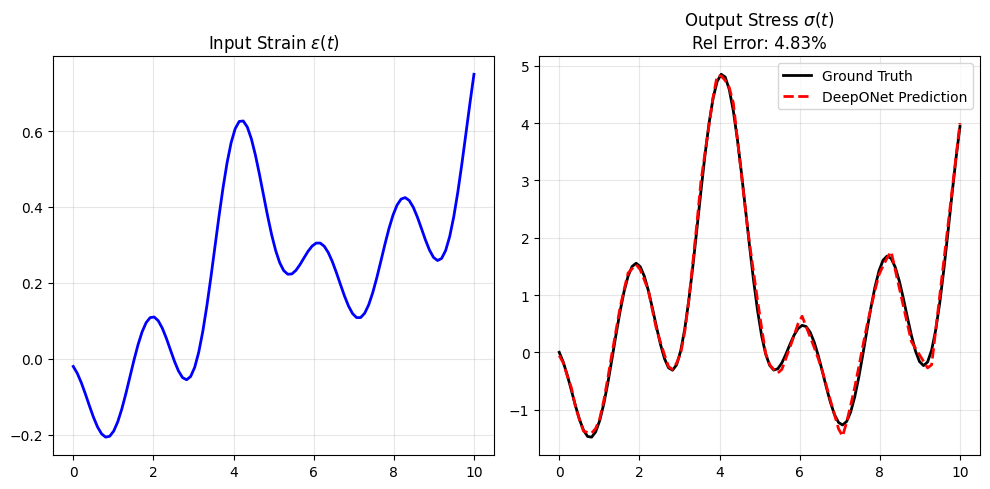

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PHYSICS GENERATION (Maxwell Model)
# ==========================================
print("Generating Viscoelastic Data...")
E = 10.0  # Modulus
tau = 2.0 # Relaxation
T_max = 10.0
num_steps = 100
dt = T_max / num_steps
t_eval = np.linspace(0, T_max, num_steps)

def solve_maxwell_stress(strain, dt, E, tau):
    sigma = np.zeros_like(strain)
    for i in range(1, len(strain)):
        d_eps = (strain[i] - strain[i-1]) / dt
        # Implicit update
        sigma[i] = (sigma[i-1] + dt * E * d_eps) / (1 + dt/tau)
    return sigma

def generate_curves(num_curves):
    curves = []
    for _ in range(num_curves):
        t = np.linspace(0, T_max, num_steps)
        curve = np.zeros_like(t)
        # More complex frequencies
        for k in range(1, 4):
            curve += np.random.normal(0, 0.2) * np.sin(k * t + np.random.uniform(0, 2*np.pi))
        # Add trend
        curve += 0.05 * t
        curves.append(curve)
    return np.array(curves)

# Generate Data
N_train = 1500 # More data
train_strain = generate_curves(N_train)
train_stress = np.array([solve_maxwell_stress(s, dt, E, tau) for s in train_strain])

# *** CRITICAL FIX: NORMALIZATION ***
# Normalize Inputs (Strain)
mu_x, std_x = np.mean(train_strain), np.std(train_strain)
train_strain_norm = (train_strain - mu_x) / std_x

# Normalize Targets (Stress)
mu_y, std_y = np.mean(train_stress), np.std(train_stress)
train_stress_norm = (train_stress - mu_y) / std_y

print(f"Data Stats | Stress Mean: {mu_y:.2f}, Stress Std: {std_y:.2f}")

# Convert to Tensor
X_branch = torch.tensor(train_strain_norm, dtype=torch.float32)
X_trunk = torch.tensor(t_eval[:, None], dtype=torch.float32)
Y_target = torch.tensor(train_stress_norm, dtype=torch.float32)

# ==========================================
# 2. DEEPONET ARCHITECTURE
# ==========================================
class DeepONet(nn.Module):
    def __init__(self, num_sensors, num_basis):
        super().__init__()
        # Increased width to 128 for better capacity
        self.branch = nn.Sequential(
            nn.Linear(num_sensors, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, num_basis)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, num_basis)
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, u, t):
        B = self.branch(u)
        T = self.trunk(t)
        return torch.einsum('bk,tk->bt', B, T) + self.bias

# ==========================================
# 3. TRAINING
# ==========================================
model = DeepONet(num_sensors=num_steps, num_basis=50)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5) # Decay LR
criterion = nn.MSELoss()

print("Training DeepONet (Normalized)...")
for epoch in range(10001): # Increased epochs
    optimizer.zero_grad()
    # Full batch gradient descent for stability
    pred = model(X_branch, X_trunk)
    loss = criterion(pred, Y_target)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# ==========================================
# 4. EVALUATION & ERROR METRICS
# ==========================================
# Test on NEW data
test_strain = generate_curves(1)
test_strain_norm = (test_strain - mu_x) / std_x
true_stress = solve_maxwell_stress(test_strain[0], dt, E, tau)

# Predict
u_test = torch.tensor(test_strain_norm, dtype=torch.float32)
with torch.no_grad():
    # Get normalized prediction
    pred_norm = model(u_test, X_trunk).squeeze().numpy()
    # *** UN-NORMALIZE ***
    pred_stress = pred_norm * std_y + mu_y

# ERROR CALCULATION
# Relative L2 Error = ||Pred - True|| / ||True||
error_l2 = np.linalg.norm(true_stress - pred_stress) / np.linalg.norm(true_stress)
print(f"\n--------------------------------")
print(f"Relative L2 Error: {error_l2*100:.2f}%")
print(f"--------------------------------")

# Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t_eval, test_strain[0], 'b-', linewidth=2)
plt.title("Input Strain $\epsilon(t)$")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t_eval, true_stress, 'k-', label="Ground Truth", linewidth=2)
plt.plot(t_eval, pred_stress, 'r--', label="DeepONet Prediction", linewidth=2)
plt.title(f"Output Stress $\sigma(t)$\nRel Error: {error_l2*100:.2f}%")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Generating Universal Training Data (Ramps, Bursts, & Partials)...
Training Universal Neural UMAT...
Epoch 0, Loss: 3.877352
Epoch 500, Loss: 0.001850
Epoch 1000, Loss: 0.000548
Epoch 1500, Loss: 0.001189
Epoch 2000, Loss: 0.003286
Epoch 2500, Loss: 0.001613
Epoch 3000, Loss: 0.002158
Epoch 3500, Loss: 0.000379
Epoch 4000, Loss: 0.000617
Epoch 4500, Loss: 0.001257
Epoch 5000, Loss: 0.000557
Epoch 5500, Loss: 0.000156
Epoch 6000, Loss: 0.000121
Epoch 6500, Loss: 0.000910
Epoch 7000, Loss: 0.000101
Epoch 7500, Loss: 0.000257
Epoch 8000, Loss: 0.000023
Epoch 8500, Loss: 0.000020
Epoch 9000, Loss: 0.000138
Epoch 9500, Loss: 0.000436
Epoch 10000, Loss: 0.000065
Epoch 10500, Loss: 0.000209
Epoch 11000, Loss: 0.000729
Epoch 11500, Loss: 0.000382
Epoch 12000, Loss: 0.000050
Epoch 12500, Loss: 0.000388
Epoch 13000, Loss: 0.000030
Epoch 13500, Loss: 0.001232
Epoch 14000, Loss: 0.000133
Epoch 14500, Loss: 0.000346

Running Benchmark...
----------------------------------------
Speedup:        22.2x

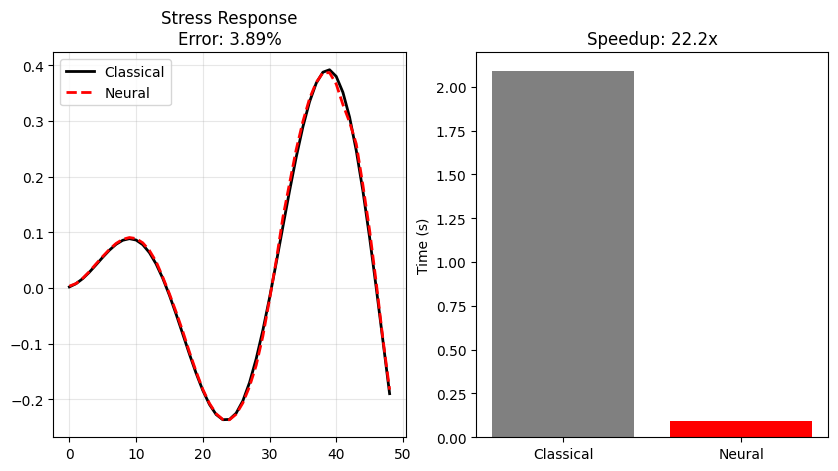

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. ROBUST PHYSICS & UNIVERSAL DATA
# ==========================================
E_modulus = 10.0
tau = 2.0
T_max = 1.0
dt = 0.01
steps = int(T_max / dt) # 100 steps

print("Generating Universal Training Data (Ramps, Bursts, & Partials)...")

def generate_universal_data(n_samples):
    X = []
    Y = []
    t_full = np.linspace(0, T_max, steps)

    for _ in range(n_samples):
        # MODE 1: Standard Sine (30% of data)
        if np.random.rand() < 0.3:
            freq = np.random.uniform(0.5, 5.0)
            amp = np.random.uniform(0.01, 0.5)
            strain_history = amp * np.sin(freq * t_full)

        # MODE 2: "Ramp Up" Sine (Like FEM) (30% of data)
        elif np.random.rand() < 0.6:
            freq = np.random.uniform(0.5, 5.0)
            max_amp = np.random.uniform(0.05, 0.5)
            # Amplitude grows linearly from 0 to max_amp
            envelope = np.linspace(0, max_amp, steps)
            strain_history = envelope * np.sin(freq * t_full)

        # MODE 3: Random Steps/Noise (40% of data)
        else:
            # Random walk to simulate arbitrary loading
            strain_history = np.cumsum(np.random.normal(0, 0.02, steps))
            # Normalize to keep within bounds
            strain_history = strain_history / (np.max(np.abs(strain_history)) + 1e-6) * 0.3

        # PARTIAL MASKING (Apply to ALL modes)
        # Randomly zero out the beginning to simulate FEM start-up
        if np.random.rand() < 0.5:
            start_idx = np.random.randint(0, steps - 5)
            mask = np.zeros(steps)
            mask[start_idx:] = 1.0
            strain_history = strain_history * mask

        # Solve Physics
        sigma_history = np.zeros_like(strain_history)
        for i in range(1, steps):
            d_eps = (strain_history[i] - strain_history[i-1]) / dt
            sigma_history[i] = (sigma_history[i-1] + dt * E_modulus * d_eps) / (1 + dt/tau)

        X.append(strain_history)
        Y.append(sigma_history[-1])

    return np.array(X), np.array(Y)

# Generate MORE data (3000 samples) to cover all modes
X_train, y_train = generate_universal_data(3000)
X_train_th = torch.tensor(X_train, dtype=torch.float32)
y_train_th = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# Architecture (Increased Depth for Complexity)
class NeuralUMAT(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(), # Wider layer
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

model = NeuralUMAT(input_size=steps)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train
print("Training Universal Neural UMAT...")
for epoch in range(6000): # More epochs
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(X_train_th), y_train_th)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# ==========================================
# 2. FEM SIMULATION (Same Benchmark)
# ==========================================
def solve_maxwell_step(strain_history, dt, E, tau):
    sigma = np.zeros_like(strain_history)
    for i in range(1, len(strain_history)):
        d_eps = (strain_history[i] - strain_history[i-1]) / dt
        sigma[i] = (sigma[i-1] + dt * E * d_eps) / (1 + dt/tau)
    return sigma[-1]

def run_simulation(mode, n_elements=100):
    n_time_steps = 50
    element_stress_trace = []
    total_strain_history = np.zeros((n_elements, steps))
    start_time = time.time()

    for t_step in range(1, n_time_steps):
        # THE CHALLENGING LOAD: Ramping Sine Wave
        current_strain = (0.05 * t_step / n_time_steps) * np.sin(t_step/5) * np.ones(n_elements)

        total_strain_history[:, :-1] = total_strain_history[:, 1:]
        total_strain_history[:, -1] = current_strain

        if mode == "classic":
            stresses = np.zeros(n_elements)
            for i in range(n_elements):
                stresses[i] = solve_maxwell_step(total_strain_history[i], dt, E_modulus, tau)
        else:
            inputs = torch.tensor(total_strain_history, dtype=torch.float32)
            with torch.no_grad():
                stresses = model(inputs).numpy().flatten()

        element_stress_trace.append(stresses[n_elements // 2])

    return time.time() - start_time, np.array(element_stress_trace)

# ==========================================
# 3. BENCHMARK
# ==========================================
print("\nRunning Benchmark...")
N_ELEM = 500

time_classic, stress_classic = run_simulation("classic", N_ELEM)
time_neural, stress_neural = run_simulation("neural", N_ELEM)

# Metrics
rel_error = np.linalg.norm(stress_classic - stress_neural) / np.linalg.norm(stress_classic) * 100

print("-" * 40)
print(f"Speedup:        {time_classic / time_neural:.1f}x")
print(f"Relative Error: {rel_error:.2f}%")
print("-" * 40)

# Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(stress_classic, 'k-', linewidth=2, label="Classical")
plt.plot(stress_neural, 'r--', linewidth=2, label="Neural")
plt.title(f"Stress Response\nError: {rel_error:.2f}%")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(["Classical", "Neural"], [time_classic, time_neural], color=['gray', 'red'])
plt.title(f"Speedup: {time_classic/time_neural:.1f}x")
plt.ylabel("Time (s)")
plt.show()